# Chapter 7: Cleaning Data

*Data Analytics with Python and Jupyter Notebook*

Run each cell in order with **Shift + Enter**. We take the raw, messy Bean There till export for January to March 2026 and turn it into data we can trust.

## 7.1 Why data is messy

### The Bean There raw export

Run this setup cell first. It imports pandas and makes wide tables fit the page.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 80)
pd.set_option("display.max_columns", 20)

## 7.2 First look: list the problems before fixing anything

The worst way to clean data is to start fixing the first problem you see. You end up chasing issues one at a time and forgetting some. Instead, look at the whole file first and write down everything that seems wrong. Then fix things in a sensible order.

In [2]:
import pandas as pd

raw = pd.read_csv("../data/ch07_bean_there_messy.csv")
raw.head(8)

,Date,Store,Product,Category,Qty,Unit Price,Revenue
0,01/01/2026,Riverside,Espresso,Coffee,10.0,$3.00,$30.00
1,01/01/2026,Riverside,Cold brew,Coffee,7.0,$4.75,$33.25
2,2026-01-01,University,Latte,Coffee,36.0,$4.50,$162.00
3,2026-01-01,University,Espresso,Coffee,19.0,$3.00,$57.00
4,2026-01-01,Downtown,Cappuccino,NaN,35.0,4.25,$148.75
5,2026-01-01,Downtown,Cold Brew,Coffee,14.0,$4.75,$66.50
6,2026-01-01,University,Cappuccino,Coffee,30.0,$4.25,$127.50
7,2026-01-01,University,Blueberry Muffin,Bakery,16.0,$2.95,$47.20


Now ask pandas for the structure, exactly as you did in Chapter 1:

In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1650 entries, 0 to 1649
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        1650 non-null   str    
 1   Store       1650 non-null   str    
 2   Product     1650 non-null   str    
 3   Category    1599 non-null   str    
 4   Qty         1610 non-null   float64
 5   Unit Price  1638 non-null   str    
 6   Revenue     1590 non-null   str    
dtypes: float64(1), str(6)
memory usage: 90.4 KB


There is one more problem that is easy to miss. Look at the column names:

In [4]:
raw.columns.tolist()

['Date', 'Store ', 'Product', 'Category', 'Qty', 'Unit Price', 'Revenue']

Next, check the text columns. `value_counts()` lists every distinct value and how often it appears, which makes inconsistent spellings jump out:

In [5]:
raw["Store "].value_counts()

Store 
University     473
Riverside      466
Downtown       453
Riverside       33
DOWNTOWN        30
downtown        27
River Side      24
University      24
 Downtown       20
Downtown        19
UNIVERSITY      19
Univ.           19
 Riverside      16
university      13
riverside       11
RIVERSIDE        3
Name: count, dtype: int64

Finally, `describe()` on the one numeric column:

In [6]:
raw["Qty"].describe()

count    1610.000000
mean       25.930435
std        14.939410
min        -3.000000
25%        18.000000
50%        24.000000
75%        31.000000
max       310.000000
Name: Qty, dtype: float64

In [7]:
sales = raw.copy()

## 7.3 Tidy the column names

Good column names are lowercase, have no spaces, and say what the column holds. That way you can type them without thinking, and they work with tab completion in Jupyter. The `.columns` attribute supports the same `.str` text methods as a text column, so we can fix every name in one go:

In [8]:
sales.columns = (
    sales.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)
sales = sales.rename(columns={"qty": "quantity"})
sales.columns.tolist()

['date', 'store', 'product', 'category', 'quantity', 'unit_price', 'revenue']

## 7.4 Fix the data types

### Numbers stored as text

Let's try converting the price column to numbers directly with `.astype(float)`:

In [9]:
# This code fails on purpose. try/except shows the error
# without stopping the rest of the notebook.
try:
    sales["unit_price"].astype(float)
except Exception as err:
    print(f"{type(err).__name__}: {err}")

ValueError: could not convert string to float: '$3.00'


pandas cannot turn `"$3.00"` into a number, because of the dollar sign. The fix is to remove the characters that do not belong, and then convert. `.str.replace()` works on every value in a text column at once:

In [10]:
price_text = sales["unit_price"].str.replace("$", "", regex=False)
price_text.head(3)

0    3.00
1    4.75
2    4.50
Name: unit_price, dtype: str

The result still has dtype `str`. To convert it, use `pd.to_numeric()`:

In [11]:
sales["unit_price"] = pd.to_numeric(price_text, errors="coerce")
print(sales["unit_price"].dtype)

float64


`errors="coerce"` is the important part. It means "if a value cannot be converted, replace it with `NaN` instead of raising an error". That keeps the conversion from stopping at the first bad value. The cost is that problems become silent, so always check how many new missing values appeared:

In [12]:
print("Missing before:", raw["Unit Price"].isna().sum())
print("Missing after: ", sales["unit_price"].isna().sum())

Missing before: 12
Missing after:  12


Same number before and after, so every price that existed converted cleanly. The revenue column needs the same treatment. Revenue can run into the thousands, and a value like `$1,317.50` also contains a comma, so we remove both characters:

In [13]:
sales["revenue"] = pd.to_numeric(
    sales["revenue"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False),
    errors="coerce",
)
sales[["unit_price", "revenue"]].describe()

,unit_price,revenue
count,1638.000000,1590.000000
mean,3.807326,100.961132
std,1.256825,66.779830
min,2.950000,-9.000000
25%,3.000000,60.000000
50%,3.250000,85.500000
75%,4.500000,126.000000
max,45.000000,1317.500000


### Dates in more than one format

In Chapter 1 we used `parse_dates=["date"]` in `read_csv`. Here the dates come in two formats, so it is safer to convert them ourselves with `pd.to_datetime()` and say exactly which format to expect. The `format` argument uses codes like `%Y` (four-digit year), `%m` (month number) and `%d` (day):

In [14]:
iso = pd.to_datetime(sales["date"], format="%Y-%m-%d", errors="coerce")
print("Dates that did not parse:", iso.isna().sum())

Dates that did not parse: 557


With `errors="coerce"`, anything that does not match `YYYY-MM-DD` becomes `NaT` ("not a time", the date version of `NaN`). 557 rows failed. Most of those are Riverside's US-style dates. Parse the same column a second time with the other format:

In [15]:
us = pd.to_datetime(sales["date"], format="%m/%d/%Y", errors="coerce")
sales["date"] = iso.fillna(us)
print("Dates that did not parse:", sales["date"].isna().sum())

Dates that did not parse: 6


`iso.fillna(us)` keeps every date that parsed the first time and fills the gaps with the result of the second attempt. Only 6 rows are still missing a date. Let's see what the original text said for those rows:

In [16]:
raw.loc[sales["date"].isna(), "Date"]

957     2026-02-30
1040    2026-13-01
1120       unknown
1275       unknown
1469    2026-02-30
1554           TBC
Name: Date, dtype: str

## 7.5 Standardize inconsistent text

### Pass 1: spaces and capitals

In [17]:
sales["store"] = sales["store"].str.strip().str.title()
sales["store"].value_counts()

store
Downtown      549
Riverside     529
University    529
River Side     24
Univ.          19
Name: count, dtype: int64

### Pass 2: a mapping for the real misspellings

What remains are spellings that no string method can guess. For those, write a dictionary that maps each wrong value to the right one and pass it to `.replace()`:

In [18]:
store_fixes = {"Univ.": "University", "River Side": "Riverside"}
sales["store"] = sales["store"].replace(store_fixes)
sales["store"].value_counts()

store
Riverside     553
Downtown      549
University    548
Name: count, dtype: int64

Three stores. Now the same two passes for products:

In [19]:
sales["product"] = sales["product"].str.strip().str.title()
sales["product"].value_counts()

product
Croissant           278
Latte               276
Blueberry Muffin    275
Espresso            273
Cappuccino          268
Cold Brew           264
Cold-Brew             8
Cappucino             8
Name: count, dtype: int64

Title case handled most of it, but two problems remain: `Cappucino` (a missing "c") and `Cold-Brew` (a hyphen).

In [20]:
product_fixes = {"Cappucino": "Cappuccino", "Cold-Brew": "Cold Brew"}
sales["product"] = sales["product"].replace(product_fixes)
sales["product"].value_counts()

product
Croissant           278
Latte               276
Cappuccino          276
Blueberry Muffin    275
Espresso            273
Cold Brew           272
Name: count, dtype: int64

A quick way to confirm a column now holds only the values you expect is to compare it with a list of allowed values using `.isin()`, which returns `True` for every value found in the list:

In [21]:
valid_stores = ["Downtown", "University", "Riverside"]
print(sales["store"].isin(valid_stores).all())

True


## 7.6 Duplicates

A **duplicate** is a row that records the same thing as another row. Here, duplicates would double-count sales. `.duplicated()` marks each row that is an exact copy of an earlier row, and `.sum()` counts the `True` values:

In [22]:
print("Exact duplicates in the raw file:", raw.duplicated().sum())
print("Exact duplicates after cleaning: ", sales.duplicated().sum())

Exact duplicates in the raw file: 22
Exact duplicates after cleaning:  30


Let's look at some duplicated rows next to their originals. `keep=False` marks *every* copy, not just the second one, so sorting puts each pair side by side:

In [23]:
dupes = sales[sales.duplicated(keep=False)]
dupes.sort_values(["date", "store", "product"]).head(4)

,date,store,product,category,quantity,unit_price,revenue
21,2026-01-02,Riverside,Latte,Coffee,21.0,4.5,94.5
35,2026-01-02,Riverside,Latte,Coffee,21.0,4.5,94.5
150,2026-01-09,Riverside,Latte,Coffee,NaN,4.5,NaN
157,2026-01-09,Riverside,Latte,Coffee,NaN,4.5,NaN


Each pair is the same sale recorded twice, sometimes even with the same missing quantity. Are the copies spread evenly, or do they cluster? Counting the extra copies by date and store answers that:

In [24]:
extra = sales[sales.duplicated()]
extra[["date", "store"]].value_counts().head(3)

date        store    
2026-02-14  Downtown     6
2026-01-02  Riverside    1
2026-01-09  Riverside    1
Name: count, dtype: int64

Most copies are single rows, but all six of Downtown's rows for 14 February appear twice: the assistant manager pasted that day's export in two times. Remove the extra copies with `.drop_duplicates()`, which keeps the first of each set by default:

In [25]:
sales = sales.drop_duplicates()
len(sales)

1620

### Duplicates on a key

Exact copies are the easy case. Often the more useful question is: **is there more than one row for something that should appear only once?** In this dataset, each combination of date, store and product should appear once. Those three columns are the table's **key**. Pass them as `subset` to check for duplicates on the key alone:

In [26]:
key = ["date", "store", "product"]
with_date = sales.dropna(subset=["date"])
print("Key duplicates:", with_date.duplicated(subset=key).sum())

Key duplicates: 0


## 7.7 Missing values

Missing values are the most common data problem of all. pandas marks them as `NaN` (or `NaT` for dates). `.isna()` returns `True` where a value is missing, and summing it per column gives a count:

In [27]:
sales.isna().sum()

date           6
store          0
product        0
category      49
quantity      39
unit_price    12
revenue       59
dtype: int64

Counts are useful; percentages help you judge how serious a gap is:

In [28]:
(sales.isna().mean() * 100).round(1)

date          0.4
store         0.0
product       0.0
category      3.0
quantity      2.4
unit_price    0.7
revenue       3.6
dtype: float64

### Three ways to deal with a gap

### Filling category from product

Every product always belongs to the same category, so a missing category can be looked up. First build the lookup from the rows where category is known:

In [29]:
category_of = (
    sales.dropna(subset=["category"])
    .drop_duplicates("product")
    .set_index("product")["category"]
)
category_of

product
Espresso            Coffee
Cold Brew           Coffee
Latte               Coffee
Cappuccino          Coffee
Blueberry Muffin    Bakery
Croissant           Bakery
Name: category, dtype: str

`.dropna(subset=["category"])` keeps only the rows where category is filled in. `.drop_duplicates("product")` keeps one row per product, and `.set_index("product")["category"]` turns the result into a Series that maps each product to its category. Now `.map()` can use that Series to look up a category for every row, and `.fillna()` uses those looked-up values only where category is missing:

In [30]:
sales["category"] = sales["category"].fillna(
    sales["product"].map(category_of)
)
print("Missing categories:", sales["category"].isna().sum())

Missing categories: 0


### Filling unit price with the product's usual price

Each product has one menu price, so a missing price can be filled with the price that product normally has. The **median** (the middle value) is a good choice because, unlike the mean, it is not dragged around by the one wrong $45.00 price we spotted earlier. `groupby` plus `.transform("median")` computes the median price per product and returns it lined up with every row:

In [31]:
usual_price = sales.groupby("product")["unit_price"].transform("median")
sales["unit_price"] = sales["unit_price"].fillna(usual_price)
print("Missing prices:", sales["unit_price"].isna().sum())

Missing prices: 0


### Dropping what cannot be recovered

A missing quantity cannot be rebuilt: the revenue for those rows is also missing, so there is nothing to work it out from. And we decided in Section 7.4 that the six rows with impossible dates must go. `.dropna(subset=...)` drops a row if any of the listed columns is missing:

In [32]:
before = len(sales)
sales = sales.dropna(subset=["date", "quantity"])
print(f"Dropped {before - len(sales)} rows, {len(sales)} remain")

Dropped 45 rows, 1575 remain


### Recomputing revenue

Revenue should always equal quantity times unit price. Rather than fill only the gaps, the safest move is to recompute the whole column, and then use the reported figures to check for disagreements:

In [33]:
calculated = (sales["quantity"] * sales["unit_price"]).round(2)
mismatch = sales["revenue"].notna() & (sales["revenue"] != calculated)
sales.loc[mismatch, ["product", "quantity", "unit_price", "revenue"]]

,product,quantity,unit_price,revenue
606,Latte,35.0,45.0,157.5


## 7.8 Outliers and impossible values

### Look first

A chart is the fastest way to see outliers. A **box plot** is made for the job: it draws the middle half of the data as a box, extends "whiskers" to the furthest values that are not unusual, and shows anything beyond the whiskers as individual points. (Chapters 11 and 12 cover charts properly; here pandas' `.plot()` is enough.)

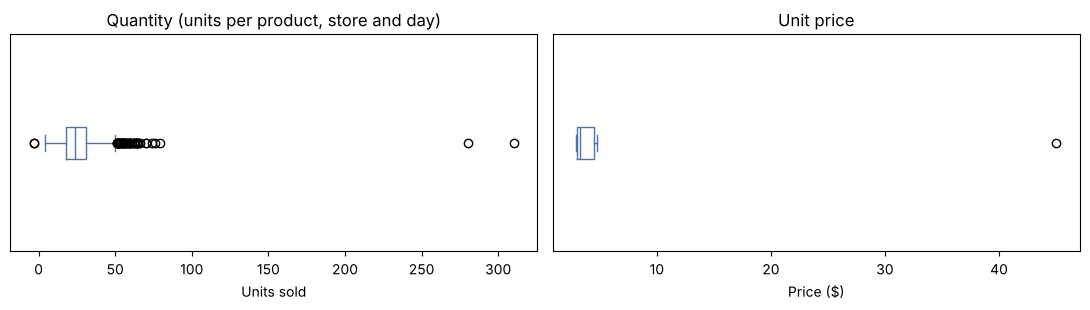

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))

sales["quantity"].plot(kind="box", vert=False, ax=axes[0],
                       color="#4C72B0")
axes[0].set_title("Quantity (units per product, store and day)")
axes[0].set_xlabel("Units sold")
axes[0].set_yticks([])

sales["unit_price"].plot(kind="box", vert=False, ax=axes[1],
                         color="#4C72B0")
axes[1].set_title("Unit price")
axes[1].set_xlabel("Price ($)")
axes[1].set_yticks([])

plt.tight_layout()
plt.savefig("../figures/ch07-quantity-outliers.png", dpi=150, bbox_inches="tight")
plt.show()

### Rules of thumb for flagging outliers

A common rule flags anything more than 1.5 **interquartile ranges** (IQR) beyond the middle half of the data. The IQR is the distance between the 25th and 75th percentiles, which pandas computes with `.quantile()`:

In [35]:
q1 = sales["quantity"].quantile(0.25)
q3 = sales["quantity"].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
print(f"Q1={q1}, Q3={q3}, upper fence={upper}")
print("Rows above the fence:", (sales["quantity"] > upper).sum())

Q1=18.0, Q3=31.0, upper fence=50.5
Rows above the fence: 52


A better test compares each value with what is normal **for the same store and product**. Here we divide each quantity by the median for its group and flag anything more than three times higher:

In [36]:
group_median = (
    sales.groupby(["store", "product"])["quantity"].transform("median")
)
ratio = sales["quantity"] / group_median
suspicious = sales[ratio > 3]
suspicious[["date", "store", "product", "quantity"]].assign(
    usual=group_median[ratio > 3]
)

,date,store,product,quantity,usual
87,2026-01-05,Downtown,Cappuccino,310.0,35.0
1527,2026-03-25,University,Croissant,280.0,22.0


### Deciding what to do

With that confirmed, the fixes are small and explicit. `.loc[rows, column] = value` changes only the selected cells:

In [37]:
typo = ratio > 3
sales.loc[typo, "quantity"] = sales.loc[typo, "quantity"] / 10

wrong_price = sales["unit_price"] > 10
sales.loc[wrong_price, "unit_price"] = usual_price

refunds = sales[sales["quantity"] < 0]
sales = sales[sales["quantity"] >= 0]
print("Refund rows set aside:", len(refunds))

Refund rows set aside: 2


Now we can recompute revenue for every row and convert quantity to a whole-number type:

In [38]:
sales["quantity"] = sales["quantity"].astype("int64")
sales["revenue"] = (sales["quantity"] * sales["unit_price"]).round(2)
sales[["quantity", "unit_price", "revenue"]].describe()

,quantity,unit_price,revenue
count,1573.000000,1573.000000,1573.000000
mean,25.528290,3.784043,99.405086
std,10.815654,0.737653,53.274768
min,4.000000,2.950000,14.750000
25%,18.000000,3.000000,60.000000
50%,24.000000,3.250000,85.500000
75%,31.000000,4.500000,126.000000
max,79.000000,4.750000,355.500000


## 7.9 Check your work

Cleaning is only finished when you have checked the result. Good checks are written as code, so they run every time. Python's `assert` statement does nothing if a condition is `True` and stops with an error if it is `False`:

In [39]:
assert sales["store"].isin(valid_stores).all()
assert sales["product"].nunique() == 6
assert sales.notna().all().all()
assert (sales["quantity"] >= 0).all()
assert not sales.duplicated(subset=key).any()
print("All checks passed")

All checks passed


### Comparing with the tidy file

Because we have the tidy Chapter 1 file, we can compare totals. We expect our cleaned data to come up a little short, since we dropped rows we could not rescue:

In [40]:
tidy = pd.read_csv("../data/bean_there_sales.csv", parse_dates=["date"])
print(f"Rows:    tidy {len(tidy):,}   cleaned {len(sales):,}")
print(f"Revenue: tidy ${tidy['revenue'].sum():,.2f}   "
      f"cleaned ${sales['revenue'].sum():,.2f}")

Rows:    tidy 1,620   cleaned 1,573
Revenue: tidy $160,913.90   cleaned $156,364.20


We have kept about 97% of the rows, and our revenue is about 3% lower than the tidy total, which matches the rows we dropped. More importantly, the store ranking and product ranking come out the same:

In [41]:
sales.groupby("store")["revenue"].sum().sort_values(ascending=False)

store
Downtown      68361.30
University    49188.55
Riverside     38814.35
Name: revenue, dtype: float64

### Saving the result

Write the cleaned data to a new file (Chapter 6 covered `to_csv` in detail):

In [42]:
sales.to_csv("../data/ch07_bean_there_clean.csv", index=False)

## 7.10 Make it reusable

Next month, the stores will send a new raw export with the same kinds of problems. You do not want to repeat this chapter by hand. Instead, collect the steps into a **function** (Chapter 3) that takes a raw DataFrame and returns a clean one.

In [43]:
STORE_FIXES = {"Univ.": "University", "River Side": "Riverside"}
PRODUCT_FIXES = {"Cappucino": "Cappuccino", "Cold-Brew": "Cold Brew"}


def to_number(text):
    """Turn text like '$1,234.50' into a number (NaN if impossible)."""
    cleaned = (text.str.replace("$", "", regex=False)
                   .str.replace(",", "", regex=False))
    return pd.to_numeric(cleaned, errors="coerce")


def to_date(text):
    """Parse dates written as 2026-01-31 or 01/31/2026."""
    iso = pd.to_datetime(text, format="%Y-%m-%d", errors="coerce")
    us = pd.to_datetime(text, format="%m/%d/%Y", errors="coerce")
    return iso.fillna(us)


def clean_names(text, fixes):
    """Strip spaces, use Title Case, then apply known fixes."""
    return text.str.strip().str.title().replace(fixes)

Small helper functions like these each do one job, have a short docstring saying what that job is, and can be tested on their own. The main function then reads almost like the problem list from Section 7.2:

In [44]:
def clean_sales(raw):
    """Clean a raw Bean There till export."""
    df = raw.copy()
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    df = df.rename(columns={"qty": "quantity"})

    # 1. Types and text
    df["date"] = to_date(df["date"])
    df["unit_price"] = to_number(df["unit_price"])
    df["store"] = clean_names(df["store"], STORE_FIXES)
    df["product"] = clean_names(df["product"], PRODUCT_FIXES)

    # 2. Duplicates
    df = df.drop_duplicates()

    # 3. Missing values
    category_of = (df.dropna(subset=["category"])
                     .drop_duplicates("product")
                     .set_index("product")["category"])
    df["category"] = df["category"].fillna(df["product"].map(category_of))
    usual = df.groupby("product")["unit_price"].transform("median")
    df["unit_price"] = df["unit_price"].fillna(usual)
    df = df.dropna(subset=["date", "quantity"])

    # 4. Outliers (rules confirmed with the owner)
    usual = df.groupby("product")["unit_price"].transform("median")
    df.loc[df["unit_price"] > 10, "unit_price"] = usual
    typical = (df.groupby(["store", "product"])["quantity"]
                 .transform("median"))
    typo = df["quantity"] / typical > 3
    df.loc[typo, "quantity"] = df.loc[typo, "quantity"] / 10
    df = df[df["quantity"] >= 0]

    # 5. Final columns
    df["quantity"] = df["quantity"].astype("int64")
    df["revenue"] = (df["quantity"] * df["unit_price"]).round(2)
    return df.reset_index(drop=True)

Running it on the raw file reproduces everything we did step by step:

In [45]:
cleaned = clean_sales(raw)
print(cleaned.shape)
print(f"Revenue: ${cleaned['revenue'].sum():,.2f}")

(1573, 7)
Revenue: $156,364.20


## 7.11 A data cleaning checklist

## 7.12 Summary

## 7.13 Exercises

Open `ch07_cleaning.ipynb` and add your answers at the bottom. Solutions are in Appendix D.

1. How many rows in the **raw** file have a price written without a `$` sign? *Hint:* `raw["Unit Price"].str.startswith("$")` returns `True` or `False` per row; watch out for missing prices.
2. Which store had the most **missing quantities** in the raw file? *Hint:* standardize the store names with `clean_names(raw["Store "], STORE_FIXES)`, then group `raw["Qty"].isna()` by those names and `.sum()`.
3. Write a function `report_missing(df)` that returns a DataFrame with two columns, `missing` (count) and `percent`, one row per column, sorted with the most-missing column first. Test it on `raw`.
4. The refunds we set aside have negative quantities. Add up their value in dollars. *Hint:* multiply quantity by unit price for the `refunds` DataFrame.
5. Use `clean_sales` and then `groupby` to find the **best-selling product at each store** by quantity. Compare your answer with Exercise 3 of Chapter 1.
6. Suppose next month's file contains the spelling `"Dwntown"`. Show how you would detect it with a check from Section 7.9, and how you would fix it by changing one line of code.
7. **Think about it:** we filled missing unit prices with the product's median price, but dropped rows with missing quantities. Explain in two or three sentences why it would be a bad idea to fill missing quantities with the median quantity.
8. **Detective work:** the six rows with impossible dates were dropped. Each one should have had a real date. For the Downtown and University rows among them, work out which date it should have had. *Hint:* use the helpers from Section 7.10 to fix the dates and names in a copy of `raw`, drop exact duplicates, but keep rows with missing values. Then, for one store and product, compare its dates with `pd.date_range("2026-01-01", "2026-03-31")` using `.difference()`.